**Autores**

----

Nicol Dayana Vasquez Zapata

1040976516

nicol.vasquez@udea.edu.co

Estudiante del Pregrado de Estadística


Daniel Soto Villada

1000534026

daniel.soto1@udea.edu.co

Estudiante del Pregrado de Astronomía

----

Universidad de Antioquia

Facultad de Ciencias Exactas y Naturales

Instituto de Matemáticas

Semestre 2026-2

Curso: Fundamentos de Estadística I

Docente: Luz Estela del Socorro Sánchez Herrera


# Inicio del proyecto Estadística Descriptiva

### Objetivo de este cuaderno
Realizar una exploración descriptiva del dataset `survey` (MASS), documentando limpieza, resúmenes, tablas de frecuencias y visualizaciones para variables cualitativas y cuantitativas.


## Contexto del dataset

### Flujo de trabajo
1. Cargar librerías y datos.  
2. Seleccionar variables de interés.  
3. Revisar calidad de datos (NA).  
4. Analizar variables cualitativas y cuantitativas.  
5. Construir gráficos y tablas finales.


## Instalación de paquetes

Se cargan los paquetes requeridos y luego el dataset base para iniciar el análisis.


In [4]:
# install.packages("MASS")
library(MASS)

In [3]:
citation("MASS")


To cite the MASS package in publications use:

  Venables, W. N. & Ripley, B. D. (2002) Modern Applied Statistics with
  S. Fourth Edition. Springer, New York. ISBN 0-387-95457-0

A BibTeX entry for LaTeX users is

  @Book{,
    title = {Modern Applied Statistics with S},
    author = {W. N. Venables and B. D. Ripley},
    publisher = {Springer},
    edition = {Fourth},
    address = {New York},
    year = {2002},
    note = {ISBN 0-387-95457-0},
    url = {https://www.stats.ox.ac.uk/pub/MASS4/},
  }


In [7]:
data(survey)

## Inspección del dataset

Primero se inspeccionan las primeras filas y después se construye una versión filtrada con las variables que se usarán durante el análisis.


In [8]:
head(survey)

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
,<fct>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>
1,Female,18.5,18.0,Right,R on L,92,Left,Some,Never,173.00,Metric,18.250
2,Male,19.5,20.5,Left,R on L,104,Left,None,Regul,177.80,Imperial,17.583
3,Male,18.0,13.3,Right,L on R,87,Neither,None,Occas,NA,NA,16.917
4,Male,18.8,18.9,Right,R on L,NA,Neither,None,Never,160.00,Metric,20.333
5,Male,20.0,20.0,Right,Neither,35,Right,Some,Never,165.00,Metric,23.667
6,Female,18.0,17.7,Right,L on R,64,Right,Some,Never,172.72,Imperial,21.000


In [9]:
survey_filtrado <- survey[, c(1, 2, 3, 4, 6, 10)]
head(survey_filtrado)

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Pulse,Height
,<fct>,<dbl>,<dbl>,<fct>,<int>,<dbl>
1,Female,18.5,18.0,Right,92,173.00
2,Male,19.5,20.5,Left,104,177.80
3,Male,18.0,13.3,Right,87,NA
4,Male,18.8,18.9,Right,NA,160.00
5,Male,20.0,20.0,Right,35,165.00
6,Female,18.0,17.7,Right,64,172.72


### Revisión de datos faltantes
Se calcula el número total de estudiantes, observaciones válidas y valores ausentes por variable.


In [10]:
# Número total de estudiantes
n_estudiantes <- nrow(survey_filtrado)
cat("Número total de estudiantes:", n_estudiantes, "\n\n")

# Número de observaciones válidas (sin valores NA) por variable
obs_validas <- colSums(!is.na(survey_filtrado))
print(obs_validas)

Número total de estudiantes: 237 

   Sex Wr.Hnd NW.Hnd  W.Hnd  Pulse Height 
   236    236    236    236    192    209 


In [11]:
# Conteo directo de NA por variable
na_por_variable <- colSums(is.na(survey_filtrado))
print(na_por_variable)

   Sex Wr.Hnd NW.Hnd  W.Hnd  Pulse Height 
     1      1      1      1     45     28 


In [11]:
# Se eliminan todas las filas que tengan NA
# Este dataset ya no tiene valores faltantes
survey_limpio <- na.omit(survey_filtrado)
# Cantidad de muestras con las que quedamos
nrow(survey_limpio)

[1] 168

### Tablas de frecuencia para variables cualitativas
Se define una función reusable para construir tablas con frecuencias absolutas y porcentajes válidos.


In [12]:
# install.packages("dplyr")
library(dplyr)


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [13]:
# Función para construir la tabla de frecuencias por variable
crear_tabla_cualitativa <- function(df, variable_col) {
  # Extraer vector de datos
  x <- df[[variable_col]]
  
  # Totales de control
  n_total <- length(x)
  n_na <- sum(is.na(x))
  n_validos <- sum(!is.na(x))
  
  # Tabla sobre casos válidos
  tabla <- df %>%
    filter(!is.na(.data[[variable_col]])) %>%
    count(.data[[variable_col]], name = "Frecuencia_n") %>%
    mutate(
      Porcentaje_Valido = round((Frecuencia_n / n_validos) * 100, 2)
    )
  
  cat("==========================================\n")
  cat("Variable:", variable_col, "\n")
  cat("==========================================\n")
  print(as.data.frame(tabla), row.names = FALSE)
  cat("\nResumen de casos:\n")
  cat(" - Casos válidos:", n_validos, "\n")
  cat(" - Valores ausentes (NA):", n_na, "\n")
  cat(" - Total de observaciones:", n_total, "\n\n")
}

crear_tabla_cualitativa(survey_filtrado, "Sex")
crear_tabla_cualitativa(survey_filtrado, "W.Hnd")

Variable: Sex 
    Sex Frecuencia_n Porcentaje_Valido
 Female          118                50
   Male          118                50

Resumen de casos:
 - Casos válidos: 236 
 - Valores ausentes (NA): 1 
 - Total de observaciones: 237 

Variable: W.Hnd 
 W.Hnd Frecuencia_n Porcentaje_Valido
  Left           18              7.63
 Right          218             92.37

Resumen de casos:
 - Casos válidos: 236 
 - Valores ausentes (NA): 1 
 - Total de observaciones: 237 



### Visualización de variables cualitativas
Se aplica un tema común y se generan gráficos para sexo y mano dominante.


In [14]:
library(ggplot2)

In [18]:
# Defino estilo general
tema_transparente <- theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    legend.background = element_rect(fill = "transparent", color = NA),
    plot.title = element_text(face = "bold", hjust = 0.5, color = "black"),
    axis.title = element_text(face = "bold", color = "black"),
    axis.text = element_text(color = "black"),
    plot.caption = element_text(color = "#4A4A4A", face = "italic") # <- Corregido aquí
  )

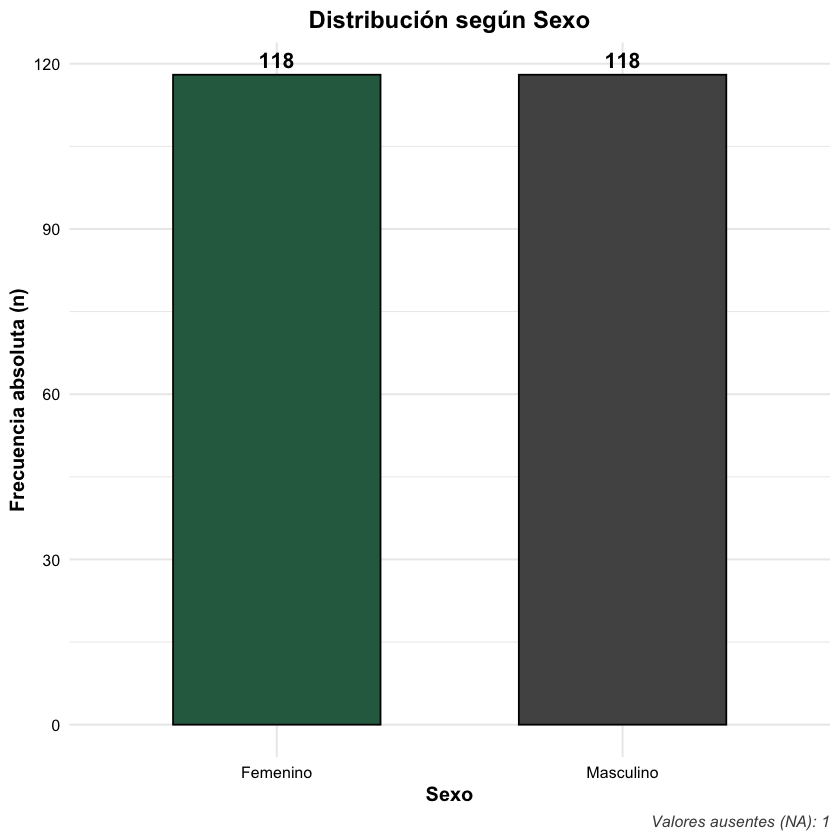

In [19]:
# Grafico para 'Sex'
p_sex <- ggplot(data = subset(survey_filtrado, !is.na(Sex)), aes(x = Sex, fill = Sex)) +
  geom_bar(width = 0.6, color = "black", linewidth = 0.5, show.legend = FALSE) +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5, size = 4.5, fontface = "bold", color = "black") +
  scale_x_discrete(labels = c("Female" = "Femenino", "Male" = "Masculino")) +
  scale_fill_manual(values = c("Female" = "#2D6A4F", "Male" = "#525252")) +
  labs(
    title = "Distribución según Sexo",
    x = "Sexo",
    y = "Frecuencia absoluta (n)",
    caption = paste("Valores ausentes (NA):", sum(is.na(survey_filtrado$Sex)))
  ) +
  tema_transparente

print(p_sex)

ggsave(
  filename = "grafico_sexo.png",
  plot = p_sex,
  width = 7,
  height = 5,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

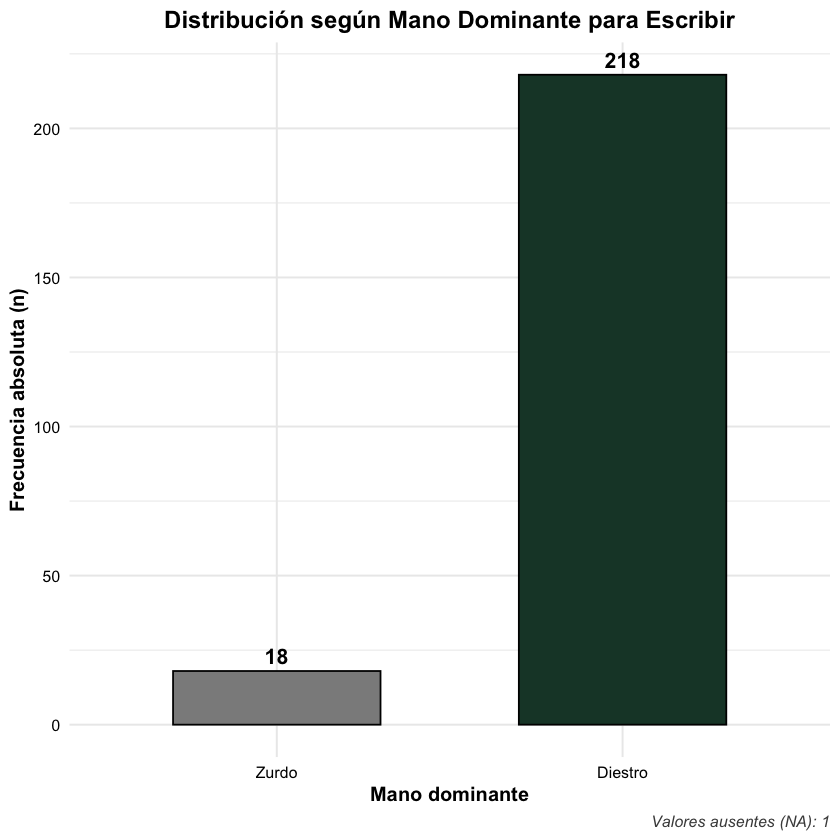

In [20]:
# Gráfico para 'W.Hnd' (Mano dominante)
p_whnd <- ggplot(data = subset(survey_filtrado, !is.na(W.Hnd)), aes(x = W.Hnd, fill = W.Hnd)) +
  geom_bar(width = 0.6, color = "black", linewidth = 0.5, show.legend = FALSE) +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5, size = 4.5, fontface = "bold", color = "black") +
  scale_x_discrete(labels = c("Left" = "Zurdo", "Right" = "Diestro")) +
  scale_fill_manual(values = c("Left" = "#8C8C8C", "Right" = "#1B4332")) +
  labs(
    title = "Distribución según Mano Dominante para Escribir",
    x = "Mano dominante",
    y = "Frecuencia absoluta (n)",
    caption = paste("Valores ausentes (NA):", sum(is.na(survey_filtrado$W.Hnd)))
  ) +
  tema_transparente

print(p_whnd)

ggsave(
  filename = "grafico_mano_dominante.png",
  plot = p_whnd,
  width = 7,
  height = 5,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

### Resumen descriptivo de variables cuantitativas
Se calculan medidas de tendencia central, dispersión y posición para `Wr.Hnd`, `NW.Hnd`, `Pulse` y `Height`.


In [21]:
library(tidyr)

In [22]:
# Función para calcular la moda muestral
calcular_moda <- function(x) {
  x_validos <- x[!is.na(x)]
  if (length(x_validos) == 0) return("Sin datos")
  
  tbl <- table(x_validos)
  max_frec <- max(tbl)
  
  # Si todos los valores tienen frecuencia 1, la moda no es informativa
  if (max_frec == 1) {
    return("No informativa")
  }
  
  modas <- names(tbl[tbl == max_frec])
  if (length(modas) > 3) {
    return("Multimodal")
  } else {
    return(paste(modas, collapse = ", "))
  }
}

# Lista de variables cuantitativas
vars_cuantitativas <- c("Wr.Hnd", "NW.Hnd", "Pulse", "Height")

In [23]:
# Generar tabla resumen
tabla_resumen_cuantitativas <- survey_filtrado %>%
  reframe(across(all_of(vars_cuantitativas), list(
    n_validos  = ~ sum(!is.na(.)),
    media      = ~ round(mean(., na.rm = TRUE), 2),
    mediana    = ~ round(median(., na.rm = TRUE), 2),
    moda       = ~ calcular_moda(.),
    minimo     = ~ round(min(., na.rm = TRUE), 2),
    maximo     = ~ round(max(., na.rm = TRUE), 2),
    rango      = ~ round(max(., na.rm = TRUE) - min(., na.rm = TRUE), 2),
    Q1         = ~ round(quantile(., 0.25, na.rm = TRUE, type = 7), 2),
    Q3         = ~ round(quantile(., 0.75, na.rm = TRUE, type = 7), 2),
    RIC        = ~ round(IQR(., na.rm = TRUE, type = 7), 2),
    varianza   = ~ round(var(., na.rm = TRUE), 2),
    desv_est   = ~ round(sd(., na.rm = TRUE), 2)
  ))) %>%
  pivot_longer(
    cols = everything(),
    names_to = c("Variable", ".value"),
    names_pattern = "(.*)_(.*)"
  )

# Mostrar la tabla formateada
print(as.data.frame(tabla_resumen_cuantitativas))

      Variable validos  media mediana     moda minimo maximo rango    Q1     Q3
1     Wr.Hnd_n     236     NA      NA     <NA>     NA     NA    NA    NA     NA
2       Wr.Hnd      NA  18.67    18.5     17.5   13.0   23.2  10.2  17.5  19.80
3  Wr.Hnd_desv      NA     NA      NA     <NA>     NA     NA    NA    NA     NA
4     NW.Hnd_n     236     NA      NA     <NA>     NA     NA    NA    NA     NA
5       NW.Hnd      NA  18.58    18.5       18   12.5   23.5  11.0  17.5  19.72
6  NW.Hnd_desv      NA     NA      NA     <NA>     NA     NA    NA    NA     NA
7      Pulse_n     192     NA      NA     <NA>     NA     NA    NA    NA     NA
8        Pulse      NA  74.15    72.5       80   35.0  104.0  69.0  66.0  80.00
9   Pulse_desv      NA     NA      NA     <NA>     NA     NA    NA    NA     NA
10    Height_n     209     NA      NA     <NA>     NA     NA    NA    NA     NA
11      Height      NA 172.38   171.0 165, 170  150.0  200.0  50.0 165.0 180.00
12 Height_desv      NA     NA      NA   

### Distribución de Pulse
Se construye la tabla de frecuencias exactas y su gráfico de barras.


In [24]:
# Tabla de frecuencias por valor exacto de Pulse
tabla_frec_pulse <- survey_filtrado %>%
  filter(!is.na(Pulse)) %>%
  count(Pulse, name = "Frecuencia_n") %>%
  mutate(
    Porcentaje = round((Frecuencia_n / sum(Frecuencia_n)) * 100, 2),
    Porcentaje_Acum = round(cumsum(Porcentaje), 2)
  )

print(as.data.frame(tabla_frec_pulse))

   Pulse Frecuencia_n Porcentaje Porcentaje_Acum
1     35            1       0.52            0.52
2     40            1       0.52            1.04
3     48            2       1.04            2.08
4     50            2       1.04            3.12
5     54            1       0.52            3.64
6     55            1       0.52            4.16
7     56            1       0.52            4.68
8     59            1       0.52            5.20
9     60           12       6.25           11.45
10    61            1       0.52           11.97
11    62            4       2.08           14.05
12    63            1       0.52           14.57
13    64            9       4.69           19.26
14    65            6       3.12           22.38
15    66            6       3.12           25.50
16    67            1       0.52           26.02
17    68           16       8.33           34.35
18    69            1       0.52           34.87
19    70           13       6.77           41.64
20    71            

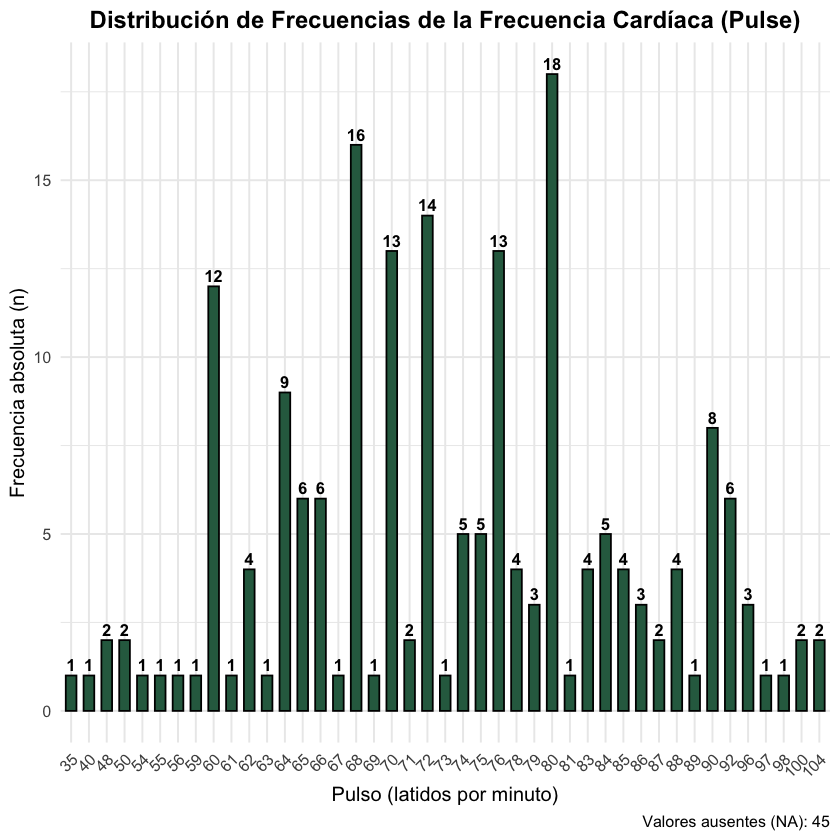

In [25]:
# Gráfico de frecuencias (Diagrama de bastones / barras discretas)
p_pulse <- ggplot(tabla_frec_pulse, aes(x = factor(Pulse), y = Frecuencia_n)) +
  geom_col(fill = "#2D6A4F", color = "black", width = 0.6) +
  geom_text(aes(label = Frecuencia_n), vjust = -0.4, size = 3.5, fontface = "bold") +
  labs(
    title = "Distribución de Frecuencias de la Frecuencia Cardíaca (Pulse)",
    x = "Pulso (latidos por minuto)",
    y = "Frecuencia absoluta (n)",
    caption = paste("Valores ausentes (NA):", sum(is.na(survey_filtrado$Pulse)))
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

print(p_pulse)

# Guardar gráfico transparente de alta definición
ggsave("grafico_frecuencias_pulse.png", plot = p_pulse, width = 9, height = 5, dpi = 300, bg = "transparent")

### Cuantiles, deciles y diagrama de tallo y hojas
Se complementa la descripción numérica con cuantiles y representaciones de distribución.


In [26]:
vars <- c("Wr.Hnd", "NW.Hnd", "Height")
probs <- sort(unique(c(seq(0.1, 0.9, 0.1), 0.25, 0.75)))

# Generar tabla de cuantiles (tipo 7)
tabla_cuantiles <- sapply(vars, function(v) {
  quantile(survey_filtrado[[v]], probs = probs, na.rm = TRUE, type = 7)
}) %>% as.data.frame() %>% round(2)

# Etiquetar filas
rownames(tabla_cuantiles) <- c("D1 (10%)", "D2 (20%)", "Q1 (25%)", "D3 (30%)", "D4 (40%)", 
                               "D5 / Mediana (50%)", "D6 (60%)", "D7 (70%)", 
                               "Q3 (75%)", "D8 (80%)", "D9 (90%)")

print(tabla_cuantiles)

                   Wr.Hnd NW.Hnd Height
D1 (10%)            16.50  16.30 160.00
D2 (20%)            17.30  17.20 165.00
Q1 (25%)            17.50  17.50 165.00
D3 (30%)            17.55  17.60 167.00
D4 (40%)            18.00  18.00 169.36
D5 / Mediana (50%)  18.50  18.50 171.00
D6 (60%)            18.90  19.00 173.80
D7 (70%)            19.50  19.50 178.00
Q3 (75%)            19.80  19.72 180.00
D8 (80%)            20.10  20.00 180.34
D9 (90%)            21.15  21.00 185.42


In [27]:
# Para evitar truncamiento/redondeo automático en R
options(digits = 5)

# 1. Diagrama para Wr.Hnd (Envergadura mano dominante)
cat("=== TALLO Y HOJAS: Wr.Hnd ===\n")
cat("Unidad del Tallo: 1 cm  |  Unidad de la Hoja: 0.1 cm (1 mm)\n")
cat("Punto decimal en '|'. Ejemplo: 18 | 5 = 18.5 cm\n\n")
stem(survey_filtrado$Wr.Hnd, scale = 2)

# 2. Diagrama para Height (Estatura)
cat("\n=== TALLO Y HOJAS: Height ===\n")
cat("Unidad del Tallo: 10 cm  |  Unidad de la Hoja: 1 cm\n")
cat("Punto decimal a la derecha. Ejemplo: 17 | 5 = 175 cm\n\n")
stem(survey_filtrado$Height, scale = 1)

=== TALLO Y HOJAS: Wr.Hnd ===
Unidad del Tallo: 1 cm  |  Unidad de la Hoja: 0.1 cm (1 mm)
Punto decimal en '|'. Ejemplo: 18 | 5 = 18.5 cm


  The decimal point is at the |

  13 | 00
  13 | 
  14 | 00
  14 | 
  15 | 04
  15 | 5569
  16 | 000000022334
  16 | 5555779
  17 | 0000000000000000123
  17 | 555555555555555555555556666778899
  18 | 000000000000000000012222333
  18 | 5555555555555555555666678888889999
  19 | 0000000000112234444
  19 | 55555555555556788
  20 | 00000000001112
  20 | 5555555555688
  21 | 000000034
  21 | 55589
  22 | 000002
  22 | 55558
  23 | 001222


=== TALLO Y HOJAS: Height ===
Unidad del Tallo: 10 cm  |  Unidad de la Hoja: 1 cm
Punto decimal a la derecha. Ejemplo: 17 | 5 = 175 cm


  The decimal point is 1 digit(s) to the right of the |

  15 | 0224
  15 | 555566777777899
  16 | 00000000333333334444
  16 | 555555555555555555677777777888888888888899999
  17 | 000000000000000000111112222222233333333334
  17 | 555555555566777778888999999
  18 | 0000000000000000023

### Detección de atípicos y boxplots
Se identifican atípicos con la regla `1.5 × RIC` y se visualizan con diagramas de caja.


In [28]:
vars_quant <- c("Wr.Hnd", "NW.Hnd", "Height", "Pulse")

# Identificación explícita de atípicos (Regla 1.5 * RIC)
identificar_atipicos <- function(df, vars) {
  lapply(vars, function(v) {
    x <- df[[v]]
    q1 <- quantile(x, 0.25, na.rm = TRUE, type = 7)
    q3 <- quantile(x, 0.75, na.rm = TRUE, type = 7)
    ric <- q3 - q1
    lim_inf <- q1 - 1.5 * ric
    lim_sup <- q3 + 1.5 * ric
    
    df %>%
      mutate(Fila = row_number()) %>%
      filter(!is.na(.data[[v]]) & (.data[[v]] < lim_inf | .data[[v]] > lim_sup)) %>%
      select(Fila, Sex, W.Hnd, Wr.Hnd, NW.Hnd, Height, Pulse) %>%
      mutate(Variable_Atipica = v, Valor = .data[[v]], Lim_Inf = round(lim_inf, 2), Lim_Sup = round(lim_sup, 2))
  }) %>% bind_rows()
}

tabla_atipicos <- identificar_atipicos(survey_filtrado, vars_quant)
print(as.data.frame(tabla_atipicos))

   Fila    Sex W.Hnd Wr.Hnd NW.Hnd Height Pulse Variable_Atipica Valor Lim_Inf
1    45 Female  <NA>   13.0   13.0 180.34    70           Wr.Hnd  13.0   14.05
2   152 Female Right   13.0   12.5 165.00    80           Wr.Hnd  13.0   14.05
3   157   Male Right   14.0   15.5     NA    NA           Wr.Hnd  14.0   14.05
4   182 Female Right   14.0   13.5 165.10    87           Wr.Hnd  14.0   14.05
5     3   Male Right   18.0   13.3     NA    87           NW.Hnd  13.3   14.16
6    45 Female  <NA>   13.0   13.0 180.34    70           NW.Hnd  13.0   14.16
7    61   Male Right   22.8   23.2 187.00    66           NW.Hnd  23.2   14.16
8    85   Male Right   23.0   23.5 167.64    90           NW.Hnd  23.5   14.16
9   152 Female Right   13.0   12.5 165.00    80           NW.Hnd  12.5   14.16
10  182 Female Right   14.0   13.5 165.10    87           NW.Hnd  13.5   14.16
11  197 Female Right   15.0   13.0 170.18    80           NW.Hnd  13.0   14.16
12  220   Male Right   23.2   23.2 188.00    75     

Warning message:
“Removed 75 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 75 rows containing non-finite values (`stat_boxplot()`).”


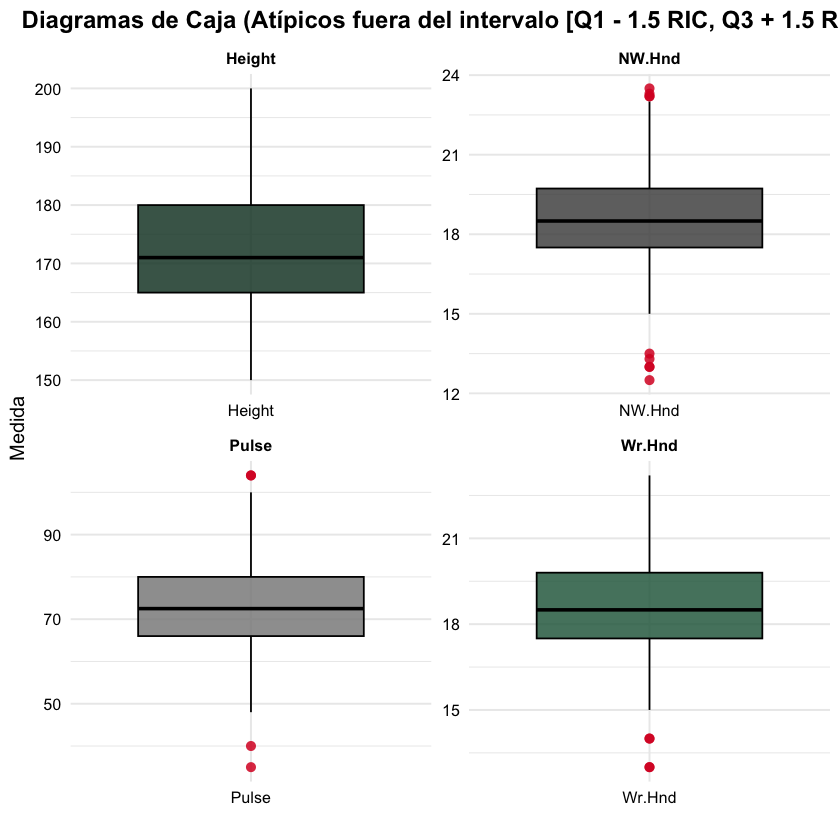

In [29]:
# Generación de Diagramas de Caja y Bigotes (Boxplots)
p_box <- survey_filtrado %>%
  select(all_of(vars_quant)) %>%
  pivot_longer(cols = everything(), names_to = "Variable", values_to = "Valor") %>%
  ggplot(aes(x = Variable, y = Valor, fill = Variable)) +
  geom_boxplot(outlier.color = "#D90429", outlier.shape = 16, outlier.size = 2.5,
               color = "black", linewidth = 0.5, alpha = 0.85, show.legend = FALSE) +
  scale_fill_manual(values = c("Wr.Hnd" = "#2D6A4F", "NW.Hnd" = "#525252", 
                               "Height" = "#1B4332", "Pulse" = "#8C8C8C")) +
  facet_wrap(~ Variable, scales = "free", ncol = 2) +
  labs(title = "Diagramas de Caja (Atípicos fuera del intervalo [Q1 - 1.5 RIC, Q3 + 1.5 RIC])",
       x = "", y = "Medida") +
  theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    strip.background = element_rect(fill = "transparent", color = NA),
    strip.text = element_text(face = "bold", color = "black"),
    plot.title = element_text(face = "bold", hjust = 0.5, color = "black"),
    axis.text = element_text(color = "black")
  )

print(p_box)

# Guardar con fondo transparente a 300 DPI
ggsave("boxplots_cuantitativas.png", plot = p_box, width = 8, height = 6, dpi = 300, bg = "transparent")

### Histogramas y frecuencias agrupadas
Se generan histogramas para variables continuas y tablas de frecuencias por intervalos.


In [30]:
tema_minimal <- theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    plot.title = element_text(face = "bold", hjust = 0.5, color = "black"),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "bold", color = "black")
  )

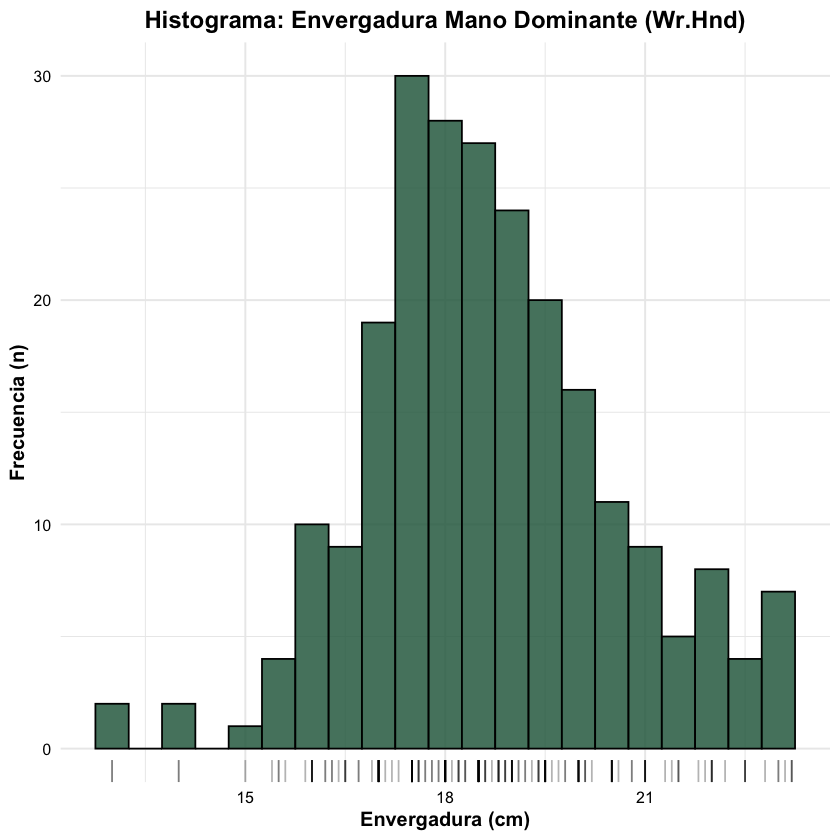

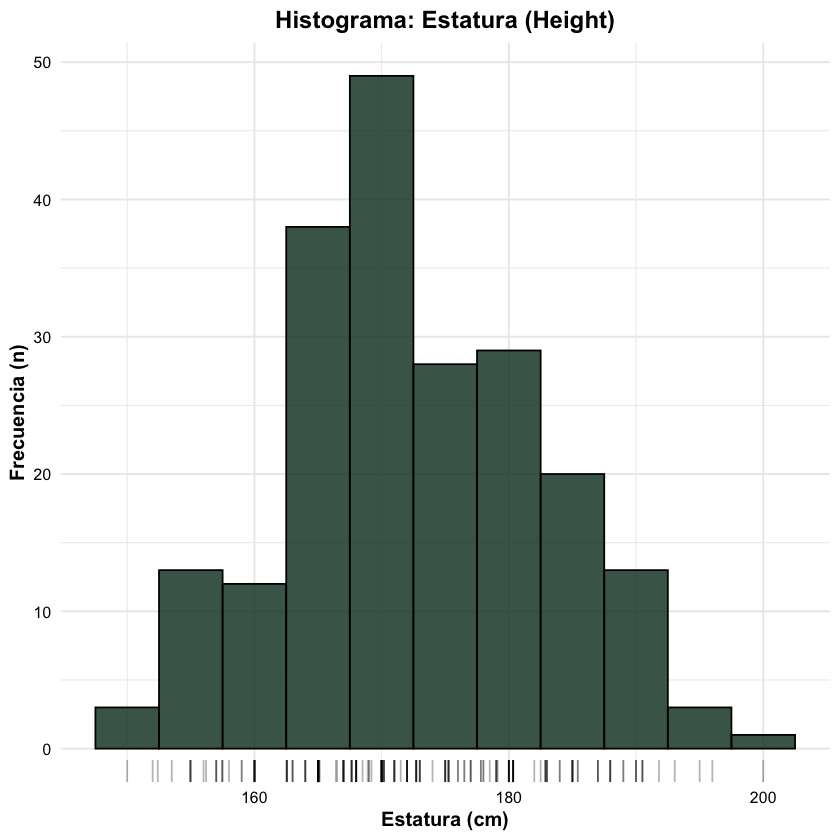

In [32]:
# Histograma para Wr.Hnd (Ancho de clase = 0.5 cm)
p_wr <- ggplot(filter(survey_filtrado, !is.na(Wr.Hnd)), aes(x = Wr.Hnd)) +
  geom_histogram(binwidth = 0.5, fill = "#2D6A4F", color = "black", alpha = 0.85) +
  geom_rug(alpha = 0.3) +
  labs(title = "Histograma: Envergadura Mano Dominante (Wr.Hnd)",
       x = "Envergadura (cm)", y = "Frecuencia (n)") +
  tema_minimal

# Histograma para Height (Ancho de clase = 5 cm)
p_height <- ggplot(filter(survey_filtrado, !is.na(Height)), aes(x = Height)) +
  geom_histogram(binwidth = 5, fill = "#1B4332", color = "black", alpha = 0.85) +
  geom_rug(alpha = 0.3) +
  labs(title = "Histograma: Estatura (Height)",
       x = "Estatura (cm)", y = "Frecuencia (n)") +
  tema_minimal

print(p_wr)
print(p_height)

# Exportar gráficos en alta resolución con fondo transparente
ggsave("histograma_WrHnd.png", plot = p_wr, width = 7, height = 4.5, dpi = 300, bg = "transparent")
ggsave("histograma_Height.png", plot = p_height, width = 7, height = 4.5, dpi = 300, bg = "transparent")

In [33]:
# Función para generar tabla de frecuencias agrupadas con límites no ambiguos
crear_tabla_frec_agrupada <- function(df, variable, ancho_bin) {
  x <- df[[variable]][!is.na(df[[variable]])]
  
  # Definición de cortes
  lim_inf <- floor(min(x))
  lim_sup <- ceiling(max(x)) + ancho_bin
  cortes <- seq(lim_inf, lim_sup, by = ancho_bin)
  
  
  df %>%
    filter(!is.na(.data[[variable]])) %>%
    mutate(Intervalo = cut(.data[[variable]], breaks = cortes, right = TRUE, include.lowest = TRUE)) %>%
    count(Intervalo, name = "Frec_Absoluta_n") %>%
    mutate(
      Frec_Relativa_f = round(Frec_Absoluta_n / sum(Frec_Absoluta_n), 4),
      Porcentaje_pct = round(Frec_Relativa_f * 100, 2),
      Frec_Abs_Acum_N = cumsum(Frec_Absoluta_n),
      Frec_Rel_Acum_F = round(cumsum(Frec_Relativa_f), 4)
    )
}


In [34]:
# Tabla para Wr.Hnd (Ancho de clase = 1 cm)
tabla_wr <- crear_tabla_frec_agrupada(survey_filtrado, "Wr.Hnd", ancho_bin = 1)
cat("=== FRECUENCIAS AGRUPADAS: Wr.Hnd ===\n")
print(as.data.frame(tabla_wr))

# Tabla para Height (Ancho de clase = 5 cm)
tabla_height <- crear_tabla_frec_agrupada(survey_filtrado, "Height", ancho_bin = 5)
cat("\n=== FRECUENCIAS AGRUPADAS: Height ===\n")
print(as.data.frame(tabla_height))

=== FRECUENCIAS AGRUPADAS: Wr.Hnd ===
   Intervalo Frec_Absoluta_n Frec_Relativa_f Porcentaje_pct Frec_Abs_Acum_N
1    [13,14]               4          0.0169           1.69               4
2    (14,15]               1          0.0042           0.42               5
3    (15,16]              12          0.0508           5.08              17
4    (16,17]              28          0.1186          11.86              45
5    (17,18]              55          0.2331          23.31             100
6    (18,19]              52          0.2203          22.03             152
7    (19,20]              36          0.1525          15.25             188
8    (20,21]              24          0.1017          10.17             212
9    (21,22]              12          0.0508           5.08             224
10   (22,23]               8          0.0339           3.39             232
11   (23,24]               4          0.0169           1.69             236
   Frec_Rel_Acum_F
1           0.0169
2           

### Cierre
Con estas salidas se obtiene una exploración ordenada del dataset, útil como base para análisis inferencial posterior.
